# <center>**DN Pathways**</center>

In [1]:
import os
from itertools import product
import numpy as np
import pandas as pd
import networkx as nx 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list

# Connectome
import connectome_analysis
import neuprint
from neuprint import NeuronCriteria as NC
sns.set_style("ticks")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
token = os.environ["HEMIBRAIN_TOKEN"]
hemibrain_analysis = connectome_analysis.neuPrintConnect(token = token)

Client version : 1.7.10


Fetch LC17 info and DN info.

In [3]:
lc17_criteria = NC(instance = "LC17.*", regex = True)
dn_criteria   = NC(instance = "DN.*", regex = True)

# Fetch info
lc17_info, _ = neuprint.fetch_neurons(lc17_criteria)
dn_info, _   = neuprint.fetch_neurons(dn_criteria)

# Remove the non-descending elements
dn_info = dn_info.loc[~(dn_info["instance"].isin(
                     ['DN1a_R', 'DN1pA_R', 'DN1pB_R', 'DN?', 'DNES1_R', 'DNES2_R', 'DNES3_R']
                       ))]

# Get the ids
lc17_ids = np.unique(lc17_info["bodyId"])
dn_ids   = np.unique(dn_info["bodyId"])

## Fetching all LC17 Outputs

In [5]:
conn_df, _ = hemibrain_analysis.connectivity(lc17_criteria, min_weight = 1, render = False)

# Groupby ROI
conn_df = conn_df.groupby(["bodyId_pre", "bodyId_post",
                           "instance_pre", "instance_post",
                           "type_pre", "type_post",])["weight"].sum().reset_index()

# Save it
conn_df.to_parquet("Pathways/LC17_all-outputs.parquet", index = False, engine = "pyarrow")
conn_df.to_csv("Pathways/LC17_all-outputs.csv", index = False)

# Take a look
conn_df

Client("https://neuprint.janelia.org", "hemibrain:v1.2.1")


,bodyId_pre,bodyId_post,instance_pre,instance_post,type_pre,type_post,weight
0,1158877703,447228814,LC17(lVLPT4)_R,PVLP106_R,LC17,PVLP106,51
1,1158877703,1068885266,LC17(lVLPT4)_R,PVLP151(SCB004)_R,LC17,PVLP151,12
2,1158877703,1070950293,LC17(lVLPT4)_R,PVLP151(SCB004)_R,LC17,PVLP151,2
3,1158877703,1219592090,LC17(lVLPT4)_R,LC17(lVLPT7)_R,LC17,LC17,2
4,1158877703,1221280490,LC17(lVLPT4)_R,LC17(lVLPT7)_R,LC17,LC17,5
...,...,...,...,...,...,...,...
15329,5813076492,5813039148,LC17,PVLP011_R,LC17,PVLP011,47
15330,5813076492,5813039410,LC17,LC17,LC17,LC17,3
15331,5813076492,5813057178,LC17,PVLP136_R,LC17,PVLP136,5
15332,5813076492,5813057579,LC17,AVLP538_R,LC17,AVLP538,12


Treating the entire LC17 population as a single unit.

In [ ]:
output_df = conn_df.groupby(["type_pre",
                             "bodyId_post", "instance_post",
                             "type_post",])["weight"].sum().reset_index()

# Take a look
output_df

,type_pre,bodyId_post,instance_post,type_post,weight
0,LC17,447228814,PVLP106_R,PVLP106,7025
1,LC17,912601209,PLP244(SCB010)_L,PLP244,58
2,LC17,1007576087,LT79_R,LT79,2
3,LC17,1014344148,AVLP151_R,AVLP151,9
4,LC17,1068885266,PVLP151(SCB004)_R,PVLP151,1090
...,...,...,...,...,...
771,LC17,5813080260,AVLP153_R,AVLP153,531
772,LC17,5901194402,NA,NA,3
773,LC17,5901207252,LC20,LC20,3
774,LC17,5901207606,NA,NA,2


Distribution of connectivity weights.

/tmp/ipykernel_254513/1504579058.py:18: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 13000)


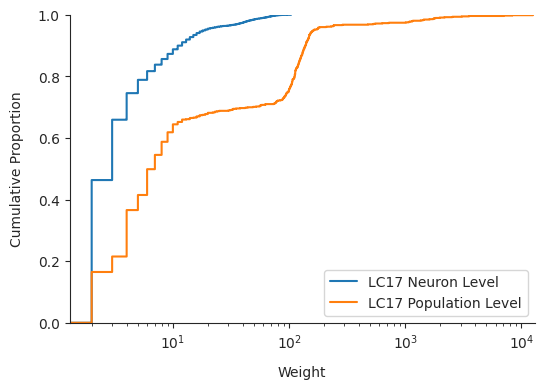

In [6]:
fig, ax = plt.subplots(figsize = (6, 4))

# ECDFplot
sns.ecdfplot(conn_df,
             x  = "weight",
             ax = ax, 
             label = "LC17 Neuron Level")

# ECDFplot
sns.ecdfplot(output_df,
             x  = "weight",
             ax = ax, 
             label = "LC17 Population Level")

# Despine
sns.despine(ax = ax)
ax.set_xscale("log")
ax.set_xlim(0, 13000)

# Legend
ax.legend()
# Labels
ax.set_xlabel("Weight", labelpad = 10)
ax.set_ylabel("Cumulative Proportion", labelpad = 10)

# Save
plt.savefig("Pathways/LC17_Output-Weights.pdf", dpi = 450, bbox_inches = "tight")


Selecting only connections with weight > 100 synapses. To capture the second bump in the ECDF

In [9]:
subset_df = output_df.loc[output_df["weight"] > 100]

# Remove LCs interconnections and NA
subset_df = subset_df.loc[~(subset_df["type_post"].str.contains("LC")) &
                          ~(subset_df["type_post"] == "NA")
                          ]

# Save it
subset_df.to_parquet("Pathways/LC17_selected-outputs-grouped.parquet", index = False,
                    engine = "pyarrow")
subset_df.to_csv("Pathways/LC17_selected-outputs-grouped.csv", index = False)

# Convert to connectivity matrix
subset_matrix = pd.crosstab(subset_df.type_pre, 
                            [subset_df.instance_post, subset_df.bodyId_post],
                            values  = subset_df.weight,
                            aggfunc = "sum")

# Output ids
common_ids = np.unique(subset_df["bodyId_post"])
# Take a look
print(f"# partners : {len(common_ids)}")

# partners : 33


In [28]:
from matplotlib.colors import LogNorm, PowerNorm
norm = LogNorm(1, 15000)

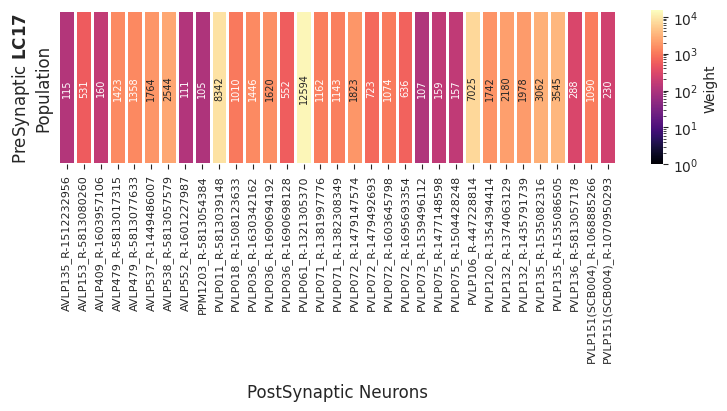

In [9]:
fig, ax = plt.subplots(figsize = (9, 2))

# Place heatmap
sns.heatmap(subset_matrix, 
            norm       = norm,
            cmap = "magma",
            linewidths = 1,
            annot = True,
            fmt   = "d",
            annot_kws = {"rotation" : 90,
                         "size"     : 7},
            cbar_kws  = {"label"  : "Weight",
                         "shrink" : 1,
                         "aspect" : 13},
            xticklabels = True) 

# Labels
ax.set_ylabel("PreSynaptic $\mathbf{LC17}$ \nPopulation", fontsize = 12);
ax.set_xlabel("PostSynaptic Neurons", labelpad = 15, fontsize = 12);
ax.set_yticks([])

# Tick params
ax.tick_params(axis = "both", labelsize = 8)


# Save
plt.savefig("Pathways/LC17_Outputs-weight-100.pdf", dpi = 450, bbox_inches = "tight")

In [10]:
pairs = list(product(common_ids, dn_ids))

# Paramsa
min_weight = 10
max_hops   = 3

# How many pairs
print(f"# pairs : {len(pairs)}")
redo = False

# pairs : 2970


In [11]:
if redo:
    path_lists = []

    # Loop over each pair
    for pair in pairs:
        # Get all the paths
        path = neuprint.queries.fetch_shortest_paths(pair[0], pair[1], min_weight = min_weight)
        
        # Get the size of each path
        path["size"] = path.groupby("path")["path"].transform("count")
        path["size"] = path["size"] - 1
        # Minus 1 for hops
        path = path.loc[path["size"] <= max_hops]
        # Remove
        if len(path) == 0:
            continue

        # Add Source and Target information
        path["source"] = pair[0]
        path["target"] = pair[1]

        # Append
        path_lists.append(path)

    # Convert to DataFrame
    all_paths = pd.concat(path_lists)

    # Save it
    all_paths.to_csv(f"Pathways/all_paths.csv", index = False)

else:
    all_paths = pd.read_csv("Pathways/all_paths.csv")

Removing all paths that go through LC17 or NA

In [12]:
thru_lc17 = all_paths.loc[all_paths["type"] == "LC17"]


# Filling in the gaps
all_paths.fillna("NA", inplace = True)

# Removing NA paths and LC17 paths
group_key   = ["source", "target", "path"]
has_lc17    = all_paths.groupby(group_key)["type"].transform(lambda x : (x == "LC17").any())
has_missing = all_paths.groupby(group_key)["type"].transform(lambda x : (x == "NA").any())

# Keep Path
keep = ~(has_lc17 | has_missing)

# Clean paths
clean_paths = all_paths[keep]

# Size Difference
dropped = len(all_paths) - len(clean_paths)

# Display
print(f"Dropped Rows : {dropped}")

Dropped Rows : 5861


Also removing most DNs.

Retaining only Gio's top set:

    DNa01-04
    DNa10
    DNb01
    DNb02
    DNp03
    DNp04
    DNp06
    DNp09
    DNp10
    DNp11
    DNp18
    DNp23
    DNp31
    DNp42

In [126]:
gio_list = ["DNa01", "DNa02", "DNa03", "DNa04", "DNa10",
            "DNb01", #"DNb02",
            "DNp07", "DNp09"]
           # "DNp03", "DNp04", "DNp06", "DNp09", "DNp10", "DNp11", "DNp18", "DNp23", "DNp31", "DNp42"]

In [127]:
retain = clean_paths.groupby(group_key)["type"].transform(lambda x : (x.isin(gio_list)).any())

# Clean paths
gio_paths = clean_paths[retain]

# Size Difference
dropped = len(clean_paths) - len(gio_paths)

# Display
print(f"Dropped Rows : {dropped}")


Dropped Rows : 26934


Counting number of paths to DNs

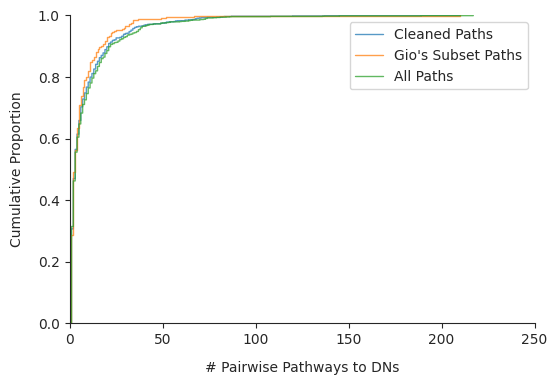

In [129]:
all_pathways   = all_paths.groupby(["source", "target", "path"])["size"].mean().reset_index()
clean_pathways = clean_paths.groupby(["source", "target", "path"])["size"].mean().reset_index()
gio_pathways   = gio_paths.groupby(["source", "target", "path"])["size"].mean().reset_index()

# Take a look at the distribution
clean_path_counts = clean_pathways[["source", "target"]].value_counts().reset_index()
all_path_counts   = all_pathways[["source", "target"]].value_counts().reset_index()
gio_path_counts   = gio_pathways[["source", "target"]].value_counts().reset_index()

# Plot the distribution
fig, ax = plt.subplots(figsize = (6, 4))

# ECDFplot
sns.ecdfplot(clean_path_counts,
             x  = "count",
             ax = ax,
             label = "Cleaned Paths",
             linewidth = 1, 
             alpha = 0.75)

# ECDFplot
sns.ecdfplot(gio_path_counts,
             x  = "count",
             ax = ax, 
             label = "Gio's Subset Paths",
             linewidth = 1, 
             alpha = 0.75)

# ECDFplot
sns.ecdfplot(all_path_counts,
             x  = "count",
             ax = ax, 
             label = "All Paths",
             linewidth = 1, 
             alpha = 0.75)

# Despine
sns.despine(ax = ax)
ax.set_xlim(0, 250)
ax.legend()

# Labels
ax.set_xlabel("# Pairwise Pathways to DNs", labelpad = 10)
ax.set_ylabel("Cumulative Proportion", labelpad = 10)

# Save
plt.savefig("Pathways/LC17_Pathways-Cleaning.pdf", dpi = 450, bbox_inches = "tight")

Getting all the relevant ids and looking at their connectivity.

In [130]:
x = gio_paths.loc[gio_paths["size"] < 3]
#all_ids = np.unique(gio_paths["bodyId"])
all_ids = np.unique(x["bodyId"])

# Create Criteria
all_criteria = NC(bodyId = all_ids)

# Fetch connections
network_df, _ = hemibrain_analysis.connectivity(all_criteria, all_criteria, min_weight = 1, render = False)

Client("https://neuprint.janelia.org", "hemibrain:v1.2.1")


In [131]:
layer_zero = np.unique(subset_df["type_post"])

In [ ]:
network_df = network_df.groupby(["bodyId_pre", "bodyId_post",
                           "instance_pre", "instance_post",
                           "type_pre", "type_post",])["weight"].sum().reset_index()

# Group by types
# Type and Instance gives same thing here
type_df = network_df.groupby(["type_pre", "type_post",
                    ])["weight"].sum().reset_index()

# Removing self connections
type_df = type_df.loc[type_df["type_pre"] != type_df["type_post"]]
# No back hopping to suset
type_df = type_df.loc[~(type_df["type_post"].isin(layer_zero))]

# Saving this for simplicity later
type_df.to_csv("Pathways/pariwise_network.csv", index = False)
type_df.to_parquet("Pathways/pariwise_network.parquet", index = False, engine = "pyarrow")

# We also want to remove the paths between DNs
type_df = type_df.loc[~(type_df["type_pre"].str.contains("DN"))]
type_df.to_csv("Pathways/pariwise_network_woDN-prop.csv", index = False)
type_df.to_parqet("Pathways/pariwise_network_woDN-prop.parquet", index = False, engine = "pyarrow")

# Removing the 5-HTP
type_df = type_df.loc[~(type_df["type_pre"].str.contains("5-HTP")) & 
                      ~(type_df["type_post"].str.contains("5-HTP"))]


# Take a look
type_df

,type_pre,type_post,weight
0,AVLP076,AVLP078,9
1,AVLP076,AVLP080,26
2,AVLP076,AVLP166,24
3,AVLP076,AVLP369,3
4,AVLP076,AVLP442,3
...,...,...,...
669,WED075,LAL136_a,7
670,WED075,LAL136_b,2
671,WED075,PLP018,48
672,WED075,PLP249,107


Making a heatmap to visualize the raw weights and actual connectivity.

In [133]:
# Matrix
type_matrix = pd.crosstab(type_df.type_pre, type_df.type_post,
                          values = type_df.weight,
                          aggfunc = "sum").fillna(0).astype(int)

# Get all the items
neus = list(set(type_df["type_pre"]) | set(type_df["type_post"]))
type_matrix = type_matrix.reindex(index = neus, columns = neus).fillna(0)

# Cluster based on similarity
cl = pd.concat((type_matrix, type_matrix.T), axis = 1)

# Params
method = "ward"
metric = "euclidean"
# Rows : Lineage
neu_linkage = linkage(cl, method = method, metric = metric)
neu_order   = leaves_list(neu_linkage)

# Clustered matrix
clustered_matrix = type_matrix.iloc[neu_order, neu_order]

# Take a look
clustered_matrix

type_post,PLP018,PVLP015,PLP249,PVLP011,PVLP135,PVLP120,PVLP061,LLPC2c,WED075,PVLP076,...,AVLP537,LAL136_a,LAL136_b,LT82a,OA-VUMa1,AVLP498,CL277,AVLP080,PVLP004,PVLP150
type_pre,,,,,,,,,,,,,,,,,,,,,
PLP018,0.0,737.0,111.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,82.0
PVLP015,6.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,4.0,3.0
PLP249,214.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,17.0,44.0,0.0,0.0,0.0,0.0,0.0,36.0,0.0
PVLP011,292.0,102.0,108.0,0.0,0.0,0.0,0.0,72.0,13.0,28.0,...,0.0,31.0,15.0,0.0,0.0,0.0,0.0,11.0,0.0,4.0
PVLP135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,213.0,0.0,53.0
PVLP120,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,94.0,0.0,0.0
PVLP061,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,43.0,0.0,112.0,4.0,34.0
LLPC2c,13.0,0.0,110.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
WED075,48.0,0.0,107.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,7.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0


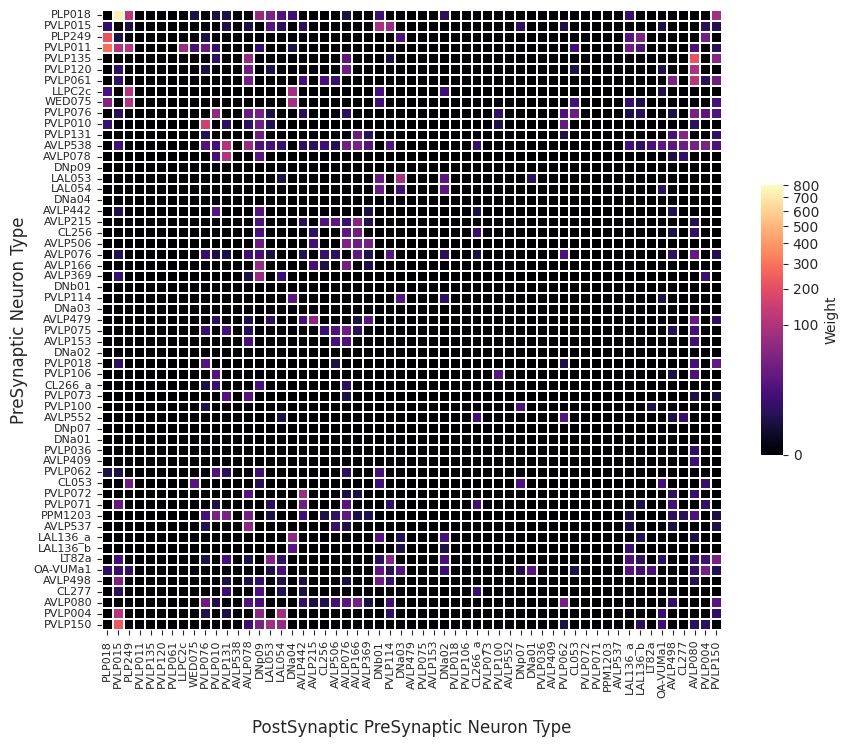

In [134]:
fig, ax = plt.subplots(figsize = (10, 10))
norm2 = PowerNorm(gamma = 0.35, vmin = 0, vmax = 800)

# Place heatmap
sns.heatmap(clustered_matrix, 
            norm   = norm2,
            cmap   = "magma",
            square = True,
            linewidths = 0.1,
            annot = False,
            fmt   = "d",
            annot_kws = {"rotation" : 90,
                         "size"     : 7},
            cbar_kws  = {"label"  : "Weight",
                         "shrink" : 0.35,
                         "aspect" : 12},
            xticklabels = True,
            yticklabels = True) 

# Labels
ax.set_ylabel("PreSynaptic Neuron Type", fontsize = 12);
ax.set_xlabel("PostSynaptic PreSynaptic Neuron Type", labelpad = 15, fontsize = 12);
# Tick params
ax.tick_params(axis = "both", labelsize = 8)

# Save
plt.savefig("Pathways/LC17_Network-Heatmap.pdf", dpi = 450, bbox_inches = "tight")

## Network Diagram

The neurons are organized into three categories:
1) Post-LC17
2) Intermediate 
3) Descending Neurons


The Y axis is based on 1-D MDS on the cosine similarity of each node's full connectivity profile (concatenated in- and out-weight vectors). Nodes with similar partners land at the same vertical position, minimising visual edge crossings across all columns.

In the **Intermediate** layer, nodes are arranged along the X axis based on spring-force layout.

In [163]:
# Spring layout parameters
spring_k = 1.8
spring_iterations = 400

# Coordinates
x_left = 0
x_dn   = 10
x_mid_range = (1, 9)

# Colors
colors = {"left" : "#3A6BB0",
          "mid"  : "#ff55dd",
          #"DN"   : "#457A30"},
          "DN"   : "#17becf"}

# Sizes
node_size = 42
edge_lw_min = 0.4
edge_lw_max = 5

In [136]:
# All nodes are stored in neus
all_nodes    = set(neus)
dn_nodes     = sorted(n for n in all_nodes if "DN" in n)
left_nodes   = sorted(n for n in all_nodes if n in layer_zero)
middle_nodes = sorted(n for n in all_nodes if n not in layer_zero and "DN" not in n)  

Spring layout.

In [137]:
G_u = nx.from_pandas_edgelist(type_df, 
                            "type_pre",
                            "type_post",
                            edge_attr = "weight",
                            create_using = nx.DiGraph)

seed = 39335
rng = np.random.default_rng(seed)

# Initial position
init_pos = {}
for n in left_nodes:
    init_pos[n] = np.array([x_left, rng.uniform(-3, 3)])
for n in dn_nodes:
    init_pos[n] = np.array([x_dn, rng.uniform(-3, 3)])
for n in middle_nodes:
    init_pos[n] = np.array([rng.uniform(-2, 2), rng.uniform(-3, 3)])


# Fixed
fixed = set(left_nodes) | set(dn_nodes)

# Spring
sp = nx.spring_layout(G_u, pos = init_pos,
                      fixed = fixed,
                      weight = "weight",
                      k = spring_k,
                      iterations = spring_iterations,
                      seed = seed)

# Rescale the intermediate x
mid_xs = np.array([sp[n][0] for n in middle_nodes])
lo, hi = x_mid_range
scaled = lo + (mid_xs - mid_xs.min()) / (np.ptp(mid_xs) + 1e-12) * (hi - lo)

# X coordinates
x_coord = {n : x_left for n in left_nodes}
x_coord.update({n : x_dn for n in dn_nodes})
x_coord.update({n : float(scaled[i]) for i, n in enumerate(middle_nodes)})

Ordering Y-axis based on the previously calculated similarity scores.

In [138]:
ordered_names = [neus[i] for i in neu_order]
rank = {n: i for i, n in enumerate(ordered_names)}

# Toal
n_total = len(ordered_names)
# Normalise ranks to [0, 100]; nodes not in clustering get the midpoint
y_norm = {
    n: (rank[n] / max(n_total - 1, 1)) * 100
    if n in rank else 50.0
    for n in all_nodes
    }

Merging Final Positions

In [139]:
pos = {n : (x_coord[n], y_norm[n]) for n in all_nodes}

In [175]:
from matplotlib.lines import Line2D

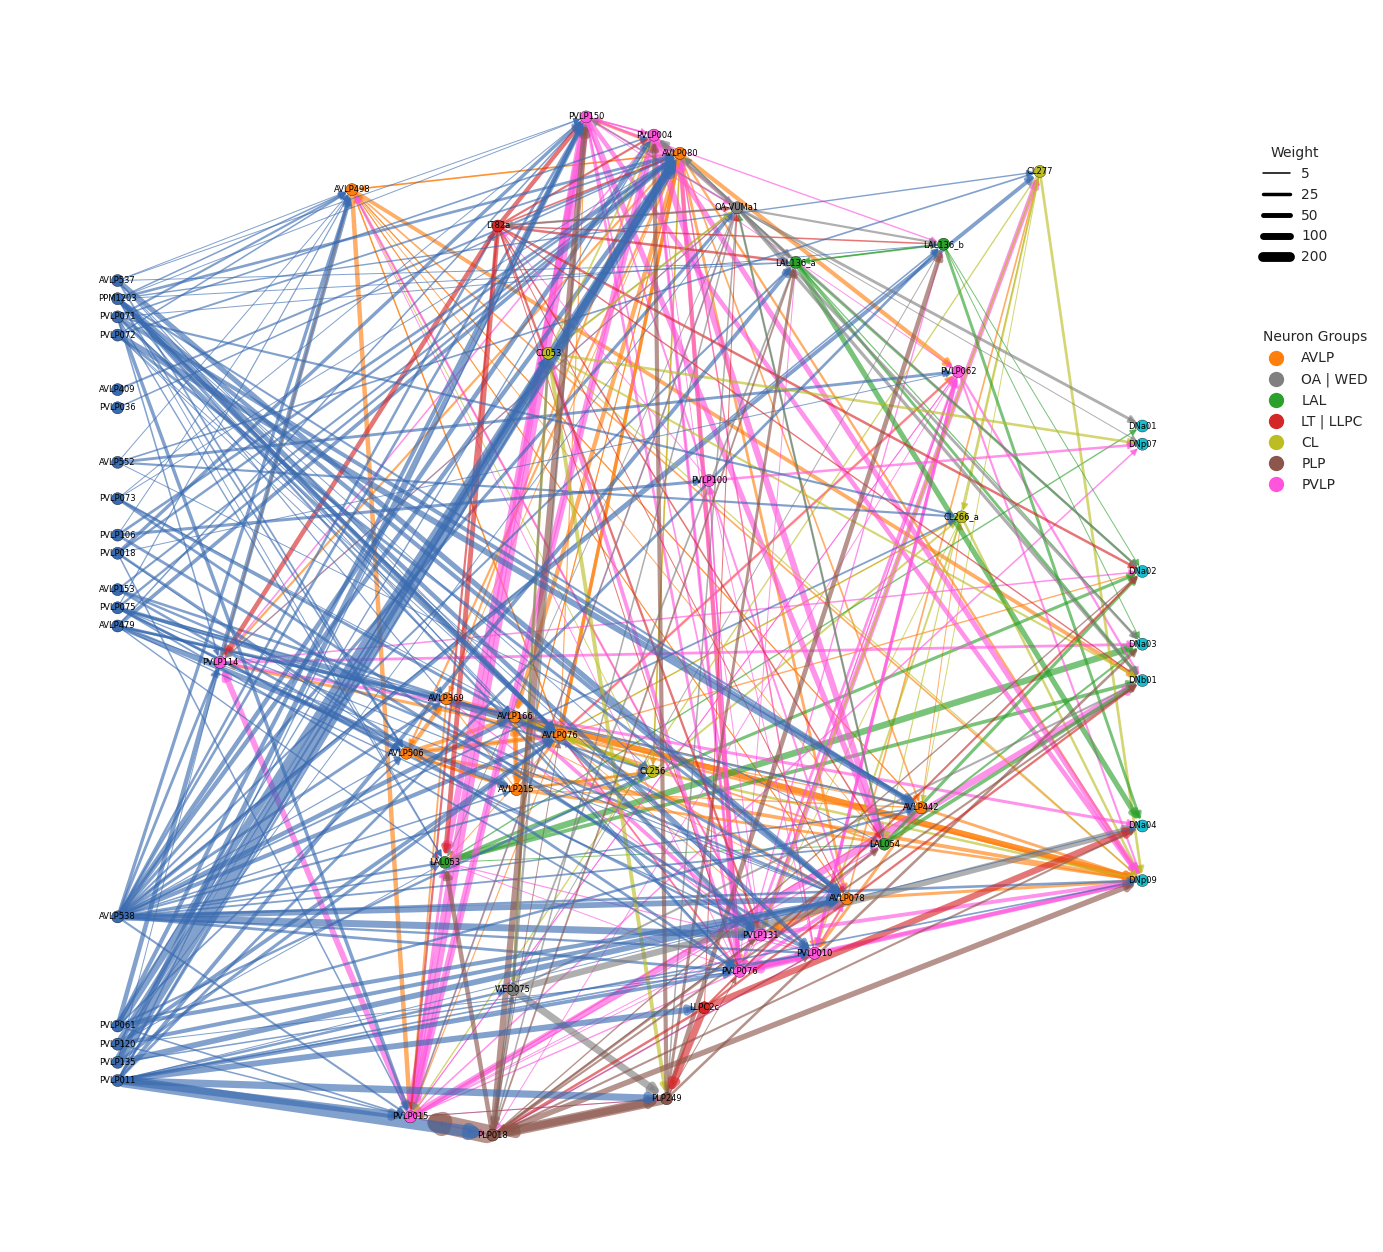

In [191]:
fig, ax = plt.subplots(figsize = (16, 16))
ax.axis("off")

# Scale
scale = 2
# Defining edge widths
edge_widths = G_u.edges(data = True)
edge_widths = np.array([w[-1]["weight"] for w in edge_widths])
edge_widths_org = edge_widths.copy()
edge_widths = np.sqrt(edge_widths) / scale

# Node and edge colors
node_colors = []
node_color_dict = {}
for node in G_u.nodes():
        if "DN" in node:
                color = colors["DN"]
        elif node in layer_zero:
                color = colors["left"]
        else:
                # This is such an ugly way to do this
                if "AVLP" in node:
                        color = "#ff7f0e"
                # OA and WED in grey
                elif "OA" in node or "WED" in node:
                        color = "#808080"
                # LAL
                elif "LAL" in node:
                        color = "#2ca02c"
                elif "LT" in node or "LLPC" in node:
                        color = "#d62728"
                elif "CL" in node:
                        color = "#bcbd22"
                elif "PLP" in node:
                        color = "#8c564b"
                # Retain PVLP as is
                else:
                        color = colors["mid"]
        # Append
        node_colors.append(color)
        node_color_dict[node] = color

# Edge colors
edge_colors = np.array([node_color_dict[node[0]] + "a1" for node in G_u.edges()])

nx.draw_networkx(G_u,
        pos = pos,
        ax  = ax,
        node_size   = 75,
        width       = edge_widths,
        font_size   = 6,
        linewidths  = 0.25,
        edgecolors  = "black",
        with_labels = True,
        edge_color  = edge_colors,
        node_color  = node_colors)

# Edges
sample = np.array([5, 25, 50, 100, 200])
sizes  = np.sqrt(sample) / scale

legend_elements = [
    Line2D([0], [0], color = 'black', linewidth = s, label = v)
    for v, s in zip(sample, sizes)
]

# Mapping - again, very lazy way to do this
categories = {
    "AVLP"      : "#ff7f0e",
    "OA | WED"  : "#808080",
    "LAL"       : "#2ca02c",
    "LT | LLPC" : "#d62728",
    "CL"        : "#bcbd22",
    "PLP"       : "#8c564b",
    "PVLP"      : "#ff55dd"}

# Circles
circle_handles = [
    Line2D([0], [0], color = c,
           marker = 'o',
           linestyle = 'none', 
           markersize = 10,
           label = k) 
    for k, c in categories.items()]


# Circle Legend
leg1 = plt.legend(handles = legend_elements, title = "Weight", loc = "upper left", bbox_to_anchor = (1, 0.9), frameon = False)
plt.gca().add_artist(leg1) 

# Weight Legend
plt.legend(handles = circle_handles, title = "Neuron Groups", loc = "upper left", bbox_to_anchor = (1, 0.75), frameon = False)

# Save it
plt.savefig("Pathways/Gios_Pathways.pdf", dpi = 450, bbox_inches = "tight")